<a href="https://colab.research.google.com/github/navoda-2001/python-sql-sales-analysis/blob/main/python_sql_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect("sales.db")
cursor = conn.cursor()

In [3]:
cursor.execute("""
CREATE TABLE Sales (
    Order_ID INTEGER,
    Customer_ID INTEGER,
    Amount INTEGER
)
""")

In [4]:
cursor.executemany("""
INSERT INTO Sales VALUES (?, ?, ?)
""", [
    (1, 101, 500),
    (2, 102, 700),
    (3, 101, 300),
    (4, 103, 200),
    (5, 104, 400)
])

conn.commit()

In [5]:
query = """
SELECT Customer_ID, SUM(Amount) AS total_spending
FROM Sales
GROUP BY Customer_ID
"""

df = pd.read_sql(query, conn)
df

,Customer_ID,total_spending
0,101,800
1,102,700
2,103,200
3,104,400


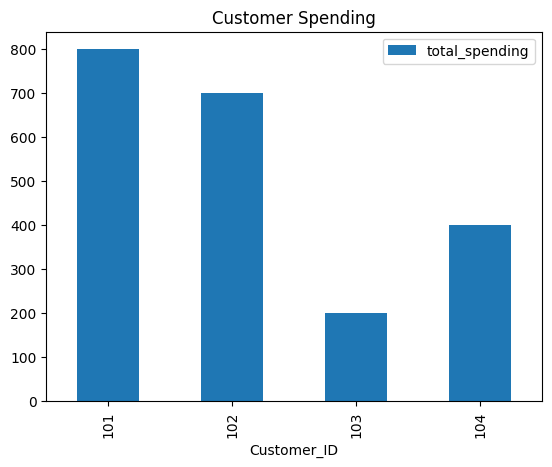

In [6]:
import matplotlib.pyplot as plt

df.plot(kind="bar", x="Customer_ID", y="total_spending")
plt.title("Customer Spending")
plt.show()

INSIGHTS

1. Customer 101 has the highest total spending.
2. Some customers show lower engagement.
3. Sales distribution is uneven across customers.